# Risk Parity Portfolio Model - Interactive Prototype

A modular implementation for risk-balanced portfolio construction and monitoring.

**Key Features:**
- Compute long-only Risk Parity weights from covariance matrices
- Calculate each asset's contribution to total portfolio risk  
- Run rolling backtests to see how RP weights evolve over time
- Detect significant shifts in portfolio composition
- Visualize weights, risk contributions, and regime shifts

**What is Risk Parity?**

Risk Parity is a portfolio construction approach that allocates based on **equal risk contribution** rather than equal capital weights. Each asset should contribute equally to total portfolio risk, regardless of its volatility or expected return.

This notebook lets you interactively explore Risk Parity on multi-asset portfolios.

## 1. Import Required Libraries

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from scipy.optimize import minimize
from functools import partial
from datetime import datetime, timedelta
import warnings

# Import core Risk Parity functions from risk_parity.py
from risk_parity_New import (
    rolling_rp_backtest,
    detect_weight_regime_shifts,
    sample_covariance,
    ewma_covariance,
    ledoit_wolf_covariance,
)
os.makedirs('plots', exist_ok=True)  # Opretter mappen hvis den ikke findes
from sklearn.covariance import LedoitWolf

# Set display options for pandas
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.float_format', lambda x: f'{x:.4f}' if abs(x) < 100 else f'{x:.2f}')

# Set matplotlib style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

warnings.filterwarnings('ignore')

## 2. Covariance Estimation

Rolling sample covariance er grundlaget for Risk Parity — den estimerer, hvor meget og i hvilken retning aktiverne bevæger sig sammen over tid.

Estimatoren bruger et simpelt rolling vindue: `cov = X'X / (T-1)` over de seneste `lookback_window` observationer. Implementeret i `risk_parity.py` og kan nemt udskiftes med fx EWMA eller shrinkage ved at ændre der.

## 3. Risk Parity Optimering

Kernen i modellen: find vægte så hvert aktiv bidrager ligeligt til den samlede porteføljerisiko.

**Objective:** Minimer summen af kvadrerede afvigelser mellem hvert aktivs risikobidrag og målet (ligeligt bidrag = 1/N).

**Constraints:**
- Vægte summer til 1
- Vægte ≥ 0 (long-only)

Implementeret som `compute_rp_weights(cov_matrix)` i `risk_parity.py`.

## 4. Rolling Backtest

Itererer over historien, estimerer kovariansen ved hvert rebalanceringstidspunkt og beregner RP-vægte. Understøtter valgfri target vol-skalering via `target_vol` parameteren.

Implementeret som `rolling_rp_backtest(returns, ...)` i `risk_parity.py`.

## 5. Regime Shift Indikator

Detekterer signifikante ændringer i RP-vægtene over tid. Bruger en z-score tilgang: flagger en periode hvis den samlede vægtændring er mere end `threshold` standardafvigelser over det rullende gennemsnit. Mere robust end en fast grænse, da den tilpasser sig porteføljens typiske turnoverniveau.

Implementeret som `detect_weight_regime_shifts(weights_df, ...)` i `risk_parity.py`.

## 7. Load and Prepare simulated Data

Generate or load synthetic multi-asset returns. For this interactive notebook, we'll create realistic synthetic data with correlations.

In [6]:
def generate_synthetic_returns(n_assets=5, n_days=1000, seed=42):
    """Generate realistic synthetic multi-asset returns."""
    np.random.seed(seed)
    
    asset_names = ['Equities', 'Bonds', 'Commodities', 'Real Estate', 'Credit'][:n_assets]
    
    # Set up realistic correlation structure
    if n_assets == 5:
        correlation_matrix = np.array([
            [1.00, -0.20, 0.10, 0.80, 0.70],
            [-0.20, 1.00, -0.10, 0.10, -0.30],
            [0.10, -0.10, 1.00, 0.20, 0.30],
            [0.80, 0.10, 0.20, 1.00, 0.50],
            [0.70, -0.30, 0.30, 0.50, 1.00],
        ])
        volatilities = np.array([0.15, 0.05, 0.20, 0.12, 0.08])
    else:
        correlation_matrix = np.eye(n_assets)
        volatilities = np.ones(n_assets) * 0.10
    
    D = np.diag(volatilities)
    covariance_matrix = D @ correlation_matrix @ D
    
    # Generate daily returns
    daily_returns = np.random.multivariate_normal(
        mean=np.zeros(n_assets),
        cov=covariance_matrix / 252,
        size=n_days
    )
    
    dates = pd.date_range(start='2020-01-01', periods=n_days, freq='B')
    returns_df = pd.DataFrame(daily_returns, index=dates, columns=asset_names)
    
    return returns_df

# Generate synthetic returns
print("Generating synthetic multi-asset returns...")
returns = generate_synthetic_returns(n_assets=5, n_days=1000)
print(f"✓ Generated {len(returns)} daily returns for {returns.shape[1]} assets")
print(f"  Period: {returns.index[0].strftime('%Y-%m-%d')} to {returns.index[-1].strftime('%Y-%m-%d')}")
print(f"\nFirst 5 rows of returns:")
print(returns.head())

Generating synthetic multi-asset returns...
✓ Generated 1000 daily returns for 5 assets
  Period: 2020-01-01 to 2023-10-31

First 5 rows of returns:
            Equities   Bonds  Commodities  Real Estate  Credit
2020-01-01   -0.0032 -0.0007      -0.0040      -0.0014 -0.0068
2020-01-02    0.0120  0.0029      -0.0080       0.0107  0.0031
2020-01-03   -0.0049 -0.0002       0.0074       0.0035  0.0047
2020-01-06   -0.0070 -0.0008       0.0124       0.0008  0.0014
2020-01-07   -0.0121  0.0017      -0.0145      -0.0067 -0.0019


## 8. Run Rolling Backtest

Execute the backtest with monthly rebalancing and a 1-year rolling window.

In [7]:
print("\nRunning rolling Risk Parity backtest...")
print("  Rebalancing frequency: Monthly")
print("  Lookback window: 252 days (1 year)")
print("  Covariance estimator: sample_covariance")
print("  Optimization: Long-only, equal risk contribution")
print()

weights_df, risk_contrib_df, portfolio_vol_df, rebalance_dates = rolling_rp_backtest(
    returns         = returns,
    rebalance_freq  = 'ME',
    lookback_window = 252,
    target_vol      = None,
    cov_estimator   = sample_covariance,  # Skift til ewma_covariance eller partial(ewma_covariance, lambda_param=0.94)
)

print(f"✓ Backtest completed: {len(weights_df)} rebalances")
print(f"  Date range: {weights_df.index[0].strftime('%Y-%m-%d')} to {weights_df.index[-1].strftime('%Y-%m-%d')}")

# Detect regime shifts
regime_shift_df, weight_changes_df = detect_weight_regime_shifts(weights_df)

print(f"\nLatest Risk Parity Weights ({weights_df.index[-1].strftime('%Y-%m-%d')}):")
print(weights_df.iloc[-1])


Running rolling Risk Parity backtest...
  Rebalancing frequency: Monthly
  Lookback window: 252 days (1 year)
  Covariance estimator: sample_covariance
  Optimization: Long-only, equal risk contribution

✓ Backtest completed: 26 rebalances
  Date range: 2020-12-31 to 2023-10-31

Latest Risk Parity Weights (2023-10-31):
Equities      0.0864
Bonds         0.5479
Commodities   0.0878
Real Estate   0.0913
Credit        0.1865
Name: 2023-10-31 00:00:00, dtype: float64


## 9. Visualize Risk Parity Weights Over Time

Track how portfolio allocations evolve. Each color represents one asset class.

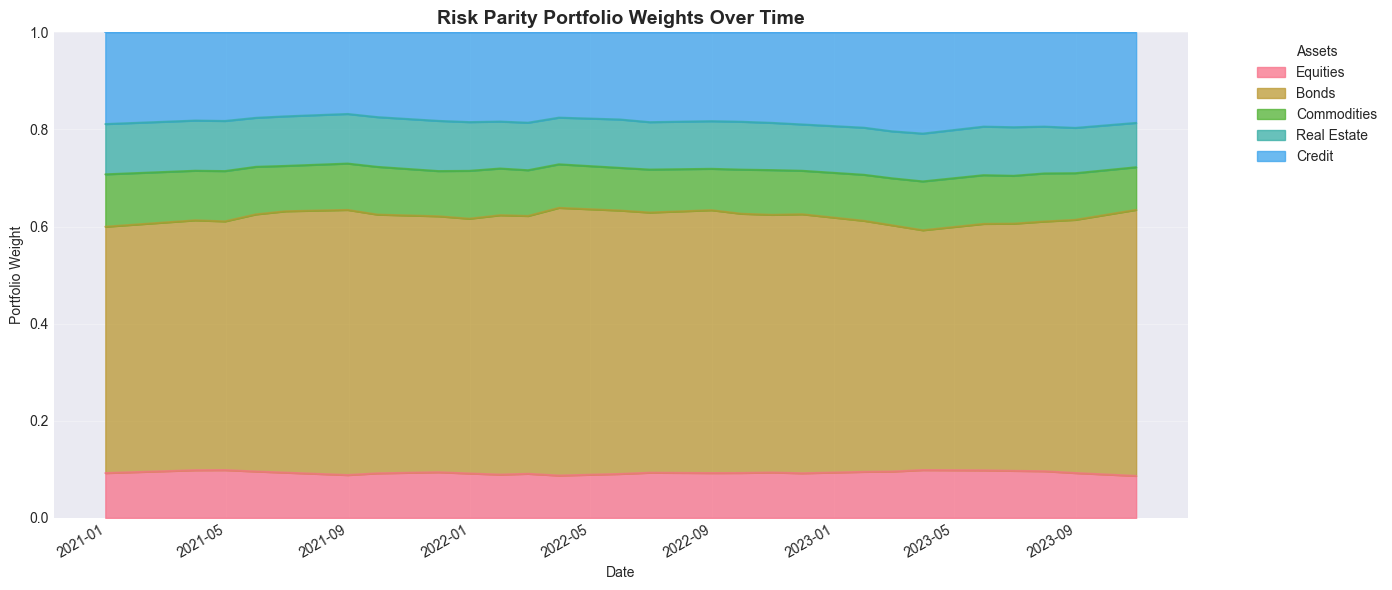


✓ Weights visualization created


In [8]:
fig, ax = plt.subplots(figsize=(14, 6))

weights_df.plot(kind='area', stacked=True, ax=ax, alpha=0.75)

ax.set_title('Risk Parity Portfolio Weights Over Time', fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Portfolio Weight')
ax.set_ylim([0, 1])
ax.legend(title='Assets', bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n✓ Weights visualization created")

## 10. Visualize Risk Contributions

Compare portfolio weights (left) with risk contributions (right) for the latest date. Risk Parity aims for equal risk contributions despite different weights.

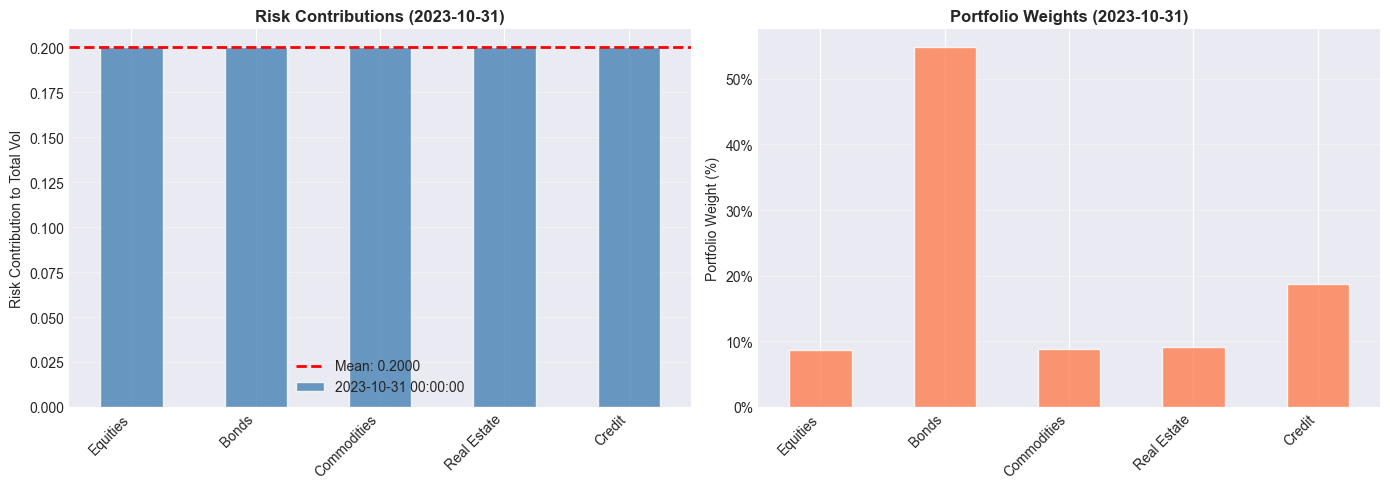

✓ Risk contributions visualization created

Risk Contribution Summary (as % of total portfolio risk):
  Equities       :  20.0%
  Bonds          :  20.0%
  Commodities    :  20.0%
  Real Estate    :  20.0%
  Credit         :  20.0%


In [9]:
latest_date = weights_df.index[-1]
latest_weights = weights_df.iloc[-1]
latest_contrib = risk_contrib_df.iloc[-1]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Risk Contributions
latest_contrib.plot(kind='bar', ax=ax1, color='steelblue', alpha=0.8)
ax1.set_title(f'Risk Contributions ({latest_date.strftime("%Y-%m-%d")})', 
              fontsize=12, fontweight='bold')
ax1.set_ylabel('Risk Contribution to Total Vol')
ax1.set_xlabel('')
ax1.grid(True, alpha=0.3, axis='y')
ax1.axhline(y=latest_contrib.mean(), color='red', linestyle='--', 
            label=f'Mean: {latest_contrib.mean():.4f}', linewidth=2)
ax1.legend()
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45, ha='right')

# Weights
latest_weights.plot(kind='bar', ax=ax2, color='coral', alpha=0.8)
ax2.set_title(f'Portfolio Weights ({latest_date.strftime("%Y-%m-%d")})', 
              fontsize=12, fontweight='bold')
ax2.set_ylabel('Portfolio Weight (%)')
ax2.set_xlabel('')
ax2.grid(True, alpha=0.3, axis='y')
[ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: '{:.0%}'.format(y)))]
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()

print("✓ Risk contributions visualization created")
print(f"\nRisk Contribution Summary (as % of total portfolio risk):")
rc_pct = (latest_contrib / latest_contrib.sum()) * 100
for asset, contrib_pct in rc_pct.items():
    print(f"  {asset:15s}: {contrib_pct:5.1f}%")

## 11. Visualize Regime Shift Indicator Over Time

Track when the portfolio allocation changes significantly. Regime shifts may indicate changes in cross-asset correlations or volatility structure.

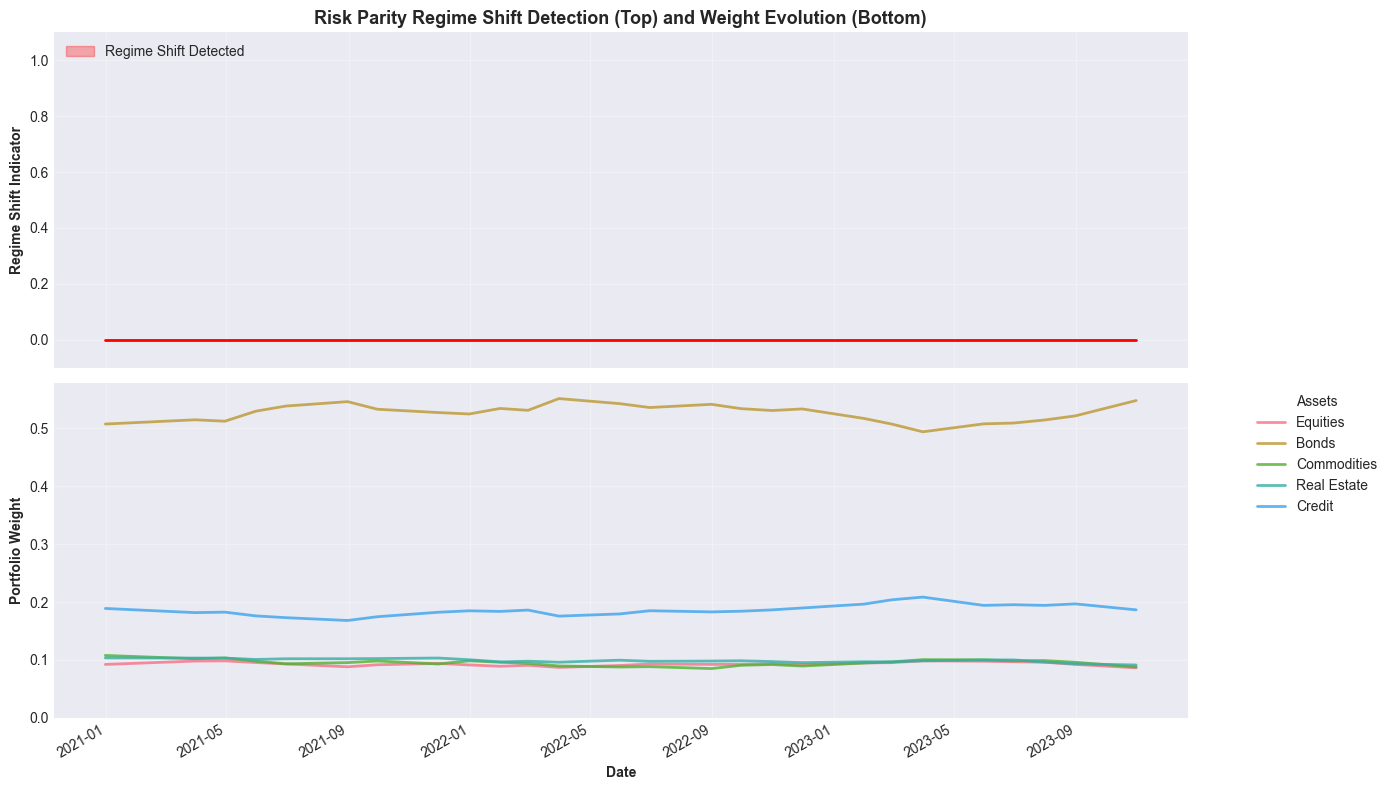

✓ Regime shift visualization created

Regime Shift Summary:
  Total shifts detected: 0 out of 26 rebalances
  Shift frequency: 0.0%


In [10]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Regime shift indicator
ax1.fill_between(regime_shift_df.index, 0, regime_shift_df['regime_shift'],
                 alpha=0.3, color='red', label='Regime Shift Detected')
ax1.plot(regime_shift_df.index, regime_shift_df['regime_shift'],
         color='red', linewidth=2, drawstyle='steps-post')
ax1.set_ylabel('Regime Shift Indicator', fontweight='bold')
ax1.set_title('Risk Parity Regime Shift Detection (Top) and Weight Evolution (Bottom)', 
              fontsize=13, fontweight='bold')
ax1.set_ylim([-0.1, 1.1])
ax1.grid(True, alpha=0.3)
ax1.legend(loc='upper left')

# Weights over time
weights_df.plot(ax=ax2, linewidth=2, alpha=0.8)
ax2.set_ylabel('Portfolio Weight', fontweight='bold')
ax2.set_xlabel('Date', fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.legend(title='Assets', bbox_to_anchor=(1.05, 1), loc='upper left')
ax2.set_ylim([0, max(weights_df.max()) * 1.05])

plt.tight_layout()
plt.show()

print("✓ Regime shift visualization created")
num_shifts = regime_shift_df['regime_shift'].sum()
print(f"\nRegime Shift Summary:")
print(f"  Total shifts detected: {int(num_shifts)} out of {len(regime_shift_df)} rebalances")
print(f"  Shift frequency: {num_shifts / len(regime_shift_df) * 100:.1f}%")

## 12. Summary Statistics & Analysis

In [12]:
print("=" * 70)
print("RISK PARITY BACKTEST SUMMARY")
print("=" * 70)

print(f"\nBacktest Period: {weights_df.index[0].strftime('%Y-%m-%d')} to {weights_df.index[-1].strftime('%Y-%m-%d')}")
print(f"Number of Rebalances: {len(weights_df)}")
print(f"Number of Assets: {len(weights_df.columns)}")

print("\n--- Latest Weights ---")
for asset, weight in latest_weights.items():
    print(f"  {asset:15s}: {weight:7.2%}")

print("\n--- Portfolio Volatility Statistics ---")
vol_series = portfolio_vol_df['Portfolio Vol']
print(f"  Mean:              {vol_series.mean():7.4f}")
print(f"  Min:               {vol_series.min():7.4f}")
print(f"  Max:               {vol_series.max():7.4f}")
print(f"  Std Dev:           {vol_series.std():7.4f}")

print("\n--- Average Weight by Asset ---")
for asset, mean_weight in weights_df.mean().items():
    print(f"  {asset:15s}: {mean_weight:7.2%}")

print("\n--- Weight Range (Min - Max) by Asset ---")
for asset in weights_df.columns:
    min_w = weights_df[asset].min()
    max_w = weights_df[asset].max()
    print(f"  {asset:15s}: {min_w:7.2%} - {max_w:7.2%}")

print("\n" + "=" * 70)

# Create summary DataFrame
summary_data = {
    'Mean Weight': weights_df.mean(),
    'Min Weight': weights_df.min(),
    'Max Weight': weights_df.max(),
    'Std Dev': weights_df.std(),
    'Latest Weight': latest_weights,
    'Latest Risk Contrib': latest_contrib
}

summary_df = pd.DataFrame(summary_data)
print("\nDetailed Summary Table:")
print(summary_df)

RISK PARITY BACKTEST SUMMARY

Backtest Period: 2020-12-31 to 2023-10-31
Number of Rebalances: 26
Number of Assets: 5

--- Latest Weights ---
  Equities       :   8.64%
  Bonds          :  54.79%
  Commodities    :   8.78%
  Real Estate    :   9.13%
  Credit         :  18.65%

--- Portfolio Volatility Statistics ---
  Mean:               0.0466
  Min:                0.0432
  Max:                0.0486
  Std Dev:            0.0013

--- Average Weight by Asset ---
  Equities       :   9.32%
  Bonds          :  52.64%
  Commodities    :   9.53%
  Real Estate    :   9.89%
  Credit         :  18.63%

--- Weight Range (Min - Max) by Asset ---
  Equities       :   8.64% -   9.85%
  Bonds          :  49.39% -  55.13%
  Commodities    :   8.52% -  10.79%
  Real Estate    :   9.13% -  10.35%
  Credit         :  16.82% -  20.86%


Detailed Summary Table:
             Mean Weight  Min Weight  Max Weight  Std Dev  Latest Weight  \
Equities          0.0932      0.0864      0.0985   0.0034         0.0

# Futures data

## Extending the Model

### 1. Use Your Own Data

```python
# Load your returns
your_returns = pd.read_csv('your_file.csv', index_col=0, parse_dates=True)

# Run backtest
weights_df, risk_contrib_df, portfolio_vol_df, dates = rolling_rp_backtest(
    returns=your_returns,
    rebalance_freq='M',
    lookback_window=252
)
```

### 2. Try Different Covariance Estimators

Currently uses rolling sample covariance. To implement EWMA or shrinkage:

```python
def estimate_ewma_covariance(returns, lambda_param=0.94):
    """Replace the sample covariance estimator"""
    # Your EWMA implementation
    pass
```

### 3. Modify Optimization

Add constraints like:
- **Maximum position weight**: `bounds = [(0, 0.3) for _ in range(n)]`
- **Minimum position weight**: `bounds = [(0.05, 1.0) for _ in range(n)]`
- **Sector constraints**: Add constraint functions

### 4. Backtest on Real Data

Use actual asset returns to build your Risk Parity strategy on real market data.

---

## Dit eget data

Her indlæser du din egen dataframe og kører den fulde Risk Parity optimering.

**Krav til dataformatet:**
- `pd.DataFrame` med daglige afkast (ikke prisniveauer)
- Index: `DatetimeIndex`
- Kolonner: aktivnavne
- Ingen NaN-værdier (eller håndter dem inden du indlæser)

In [2]:
# -------------------------------------------------------
# Indsæt din dataframe her
# -------------------------------------------------------
my_returns = pd.read_csv('data/futures_returns.csv', index_col=0, parse_dates=True)

# Tjek at dataen ser rigtig ud
print(f"Periode:  {my_returns.index[0].strftime('%Y-%m-%d')} → {my_returns.index[-1].strftime('%Y-%m-%d')}")
print(f"Aktiver:  {list(my_returns.columns)}")
print(f"Observationer: {len(my_returns)}")
print(f"\nManglende værdier:\n{my_returns.isnull().sum()}")
print(f"\nDe første 5 rækker:")
my_returns.head()

Periode:  2006-09-15 → 2026-03-26
Aktiver:  ['S&P 500', 'NASDAQ 100', 'Euro Stoxx 50', 'Nikkei 225', 'FTSE China A50', 'DAX', 'Hang Seng', 'FTSE 100', 'EURO BUND 10Y', 'EURO BOBL 5Y', 'EURO SCHATZ 2Y', 'US T-Note 10Y', 'US T-Note 5Y', 'US T-Note 2Y']
Observationer: 5095

Manglende værdier:
S&P 500           2
NASDAQ 100        2
Euro Stoxx 50     2
Nikkei 225        2
FTSE China A50    2
DAX               2
Hang Seng         2
FTSE 100          2
EURO BUND 10Y     2
EURO BOBL 5Y      2
EURO SCHATZ 2Y    2
US T-Note 10Y     2
US T-Note 5Y      2
US T-Note 2Y      2
dtype: int64

De første 5 rækker:


,S&P 500,NASDAQ 100,Euro Stoxx 50,Nikkei 225,FTSE China A50,DAX,Hang Seng,FTSE 100,EURO BUND 10Y,EURO BOBL 5Y,EURO SCHATZ 2Y,US T-Note 10Y,US T-Note 5Y,US T-Note 2Y
2006-09-15,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2006-09-18,-0.0043,-0.0003,0.0008,0.0000,0.0015,-0.0004,0.0073,0.0050,-0.0013,-0.0010,-0.0005,-0.0015,-0.0007,-0.0005
2006-09-19,0.0030,-0.0064,-0.0104,-0.0025,0.0035,-0.0091,-0.0040,-0.0164,0.0035,0.0020,0.0011,0.0053,0.0033,0.0017
2006-09-20,0.0006,0.0126,0.0187,-0.0082,0.0002,0.0140,0.0138,0.0113,-0.0009,-0.0005,-0.0003,-0.0001,-0.0004,-0.0004
2006-09-21,0.0025,-0.0051,-0.0041,0.0057,0.0085,-0.0059,0.0031,0.0008,0.0054,0.0034,0.0013,0.0063,0.0046,0.0022


### Kør backtesten

Sæt dine parametre nedenfor. Kør med og uden `target_vol` for at sammenligne.

In [3]:
# -------------------------------------------------------
# Parametre — justér efter behov
# -------------------------------------------------------
REBALANCE_FREQ  = 'W'             # 'ME' = månedlig, 'QE' = kvartalsvis
LOOKBACK_WINDOW = 90              # Antal handelsdage til kovariansestimering (252 = 1 år)
TARGET_VOL      = None             # Sæt fx 0.10 for 10% target vol, eller None for uvægtet
COV_ESTIMATOR   = sample_covariance  # Skift til: partial(ewma_covariance, lambda_param=0.94 eller ledoit_wolf_covariance eller sample_covariance)

# -------------------------------------------------------
# Kør optimering½
# -------------------------------------------------------
my_weights, my_risk_contrib, my_portfolio_vol, my_rebal_dates = rolling_rp_backtest(
    returns         = my_returns,
    rebalance_freq  = REBALANCE_FREQ,
    lookback_window = LOOKBACK_WINDOW,
    target_vol      = TARGET_VOL,
    cov_estimator   = COV_ESTIMATOR,
)

my_regime_shifts, my_weight_changes = detect_weight_regime_shifts(my_weights)

print(f"✓ Backtest færdig: {len(my_weights)} rebalanceringer")
print(f"  Periode: {my_weights.index[0].strftime('%Y-%m-%d')} → {my_weights.index[-1].strftime('%Y-%m-%d')}")
print(f"\nSeneste vægte ({my_weights.index[-1].strftime('%Y-%m-%d')}):")
print(my_weights.iloc[-1].to_string())

✓ Backtest færdig: 1001 rebalanceringer
  Periode: 2007-01-19 → 2026-03-20

Seneste vægte (2026-03-20):
S&P 500          0.0237
NASDAQ 100       0.0198
Euro Stoxx 50    0.0153
Nikkei 225       0.0188
FTSE China A50   0.0422
DAX              0.0167
Hang Seng        0.0167
FTSE 100         0.0213
EURO BUND 10Y    0.0573
EURO BOBL 5Y     0.0994
EURO SCHATZ 2Y   0.2074
US T-Note 10Y    0.0654
US T-Note 5Y     0.1020
US T-Note 2Y     0.2940


### Resultater

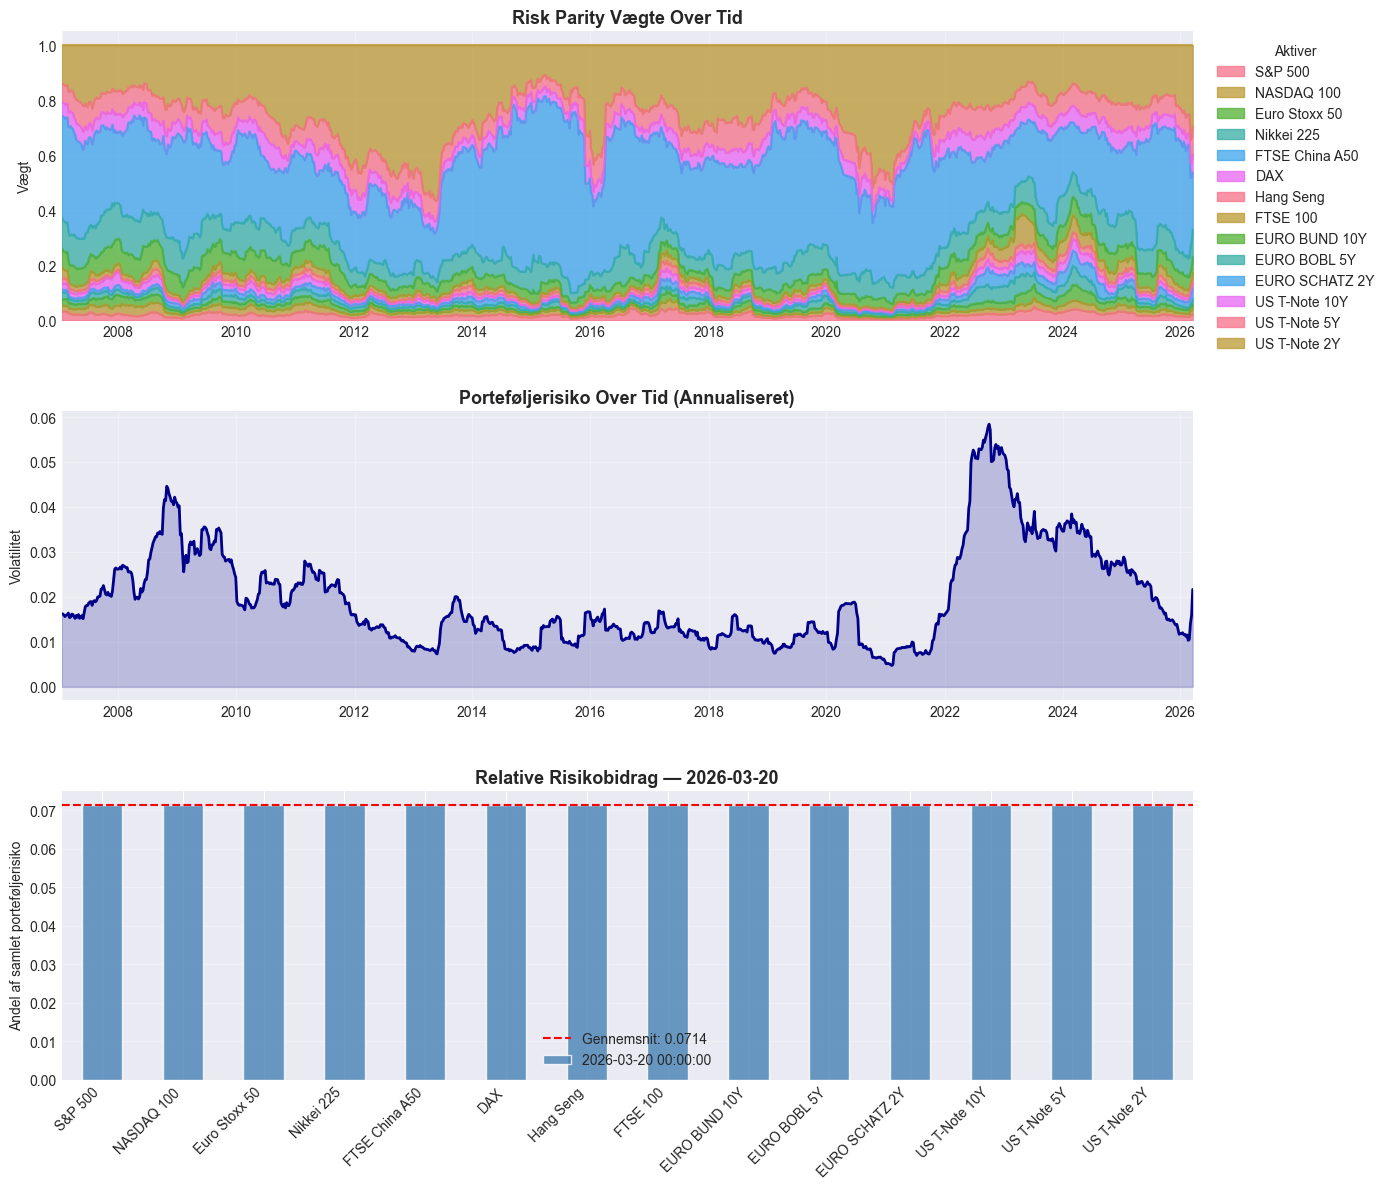

In [5]:
fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=False)

# --- Vægte over tid ---
my_weights.plot(kind='area', stacked=True, ax=axes[0], alpha=0.75)
axes[0].set_title('Risk Parity Vægte Over Tid', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Vægt')
axes[0].set_ylim([0, None])
axes[0].legend(title='Aktiver', bbox_to_anchor=(1.01, 1), loc='upper left')
axes[0].grid(True, alpha=0.3)

# --- Porteføljevolatilitet over tid ---
my_portfolio_vol['Portfolio Vol'].plot(ax=axes[1], color='darkblue', linewidth=2)
axes[1].fill_between(my_portfolio_vol.index, my_portfolio_vol['Portfolio Vol'], alpha=0.2, color='darkblue')
if TARGET_VOL is not None:
    axes[1].axhline(y=TARGET_VOL, color='red', linestyle='--', linewidth=1.5, label=f'Target vol: {TARGET_VOL:.0%}')
    axes[1].legend()
axes[1].set_title('Porteføljerisiko Over Tid (Annualiseret)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Volatilitet')
axes[1].grid(True, alpha=0.3)

# --- Risikobidrag seneste dato ---
latest_contrib = my_risk_contrib.iloc[-1]
latest_date    = my_risk_contrib.index[-1]
latest_contrib.plot(kind='bar', ax=axes[2], color='steelblue', alpha=0.8)
axes[2].axhline(y=latest_contrib.mean(), color='red', linestyle='--', linewidth=1.5,
                label=f'Gennemsnit: {latest_contrib.mean():.4f}')
axes[2].set_title(f'Relative Risikobidrag — {latest_date.strftime("%Y-%m-%d")}', fontsize=13, fontweight='bold')
axes[2].set_ylabel('Andel af samlet porteføljerisiko')
axes[2].legend()
axes[2].grid(True, alpha=0.3, axis='y')
plt.setp(axes[2].xaxis.get_majorticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()

### Bedre visualisering

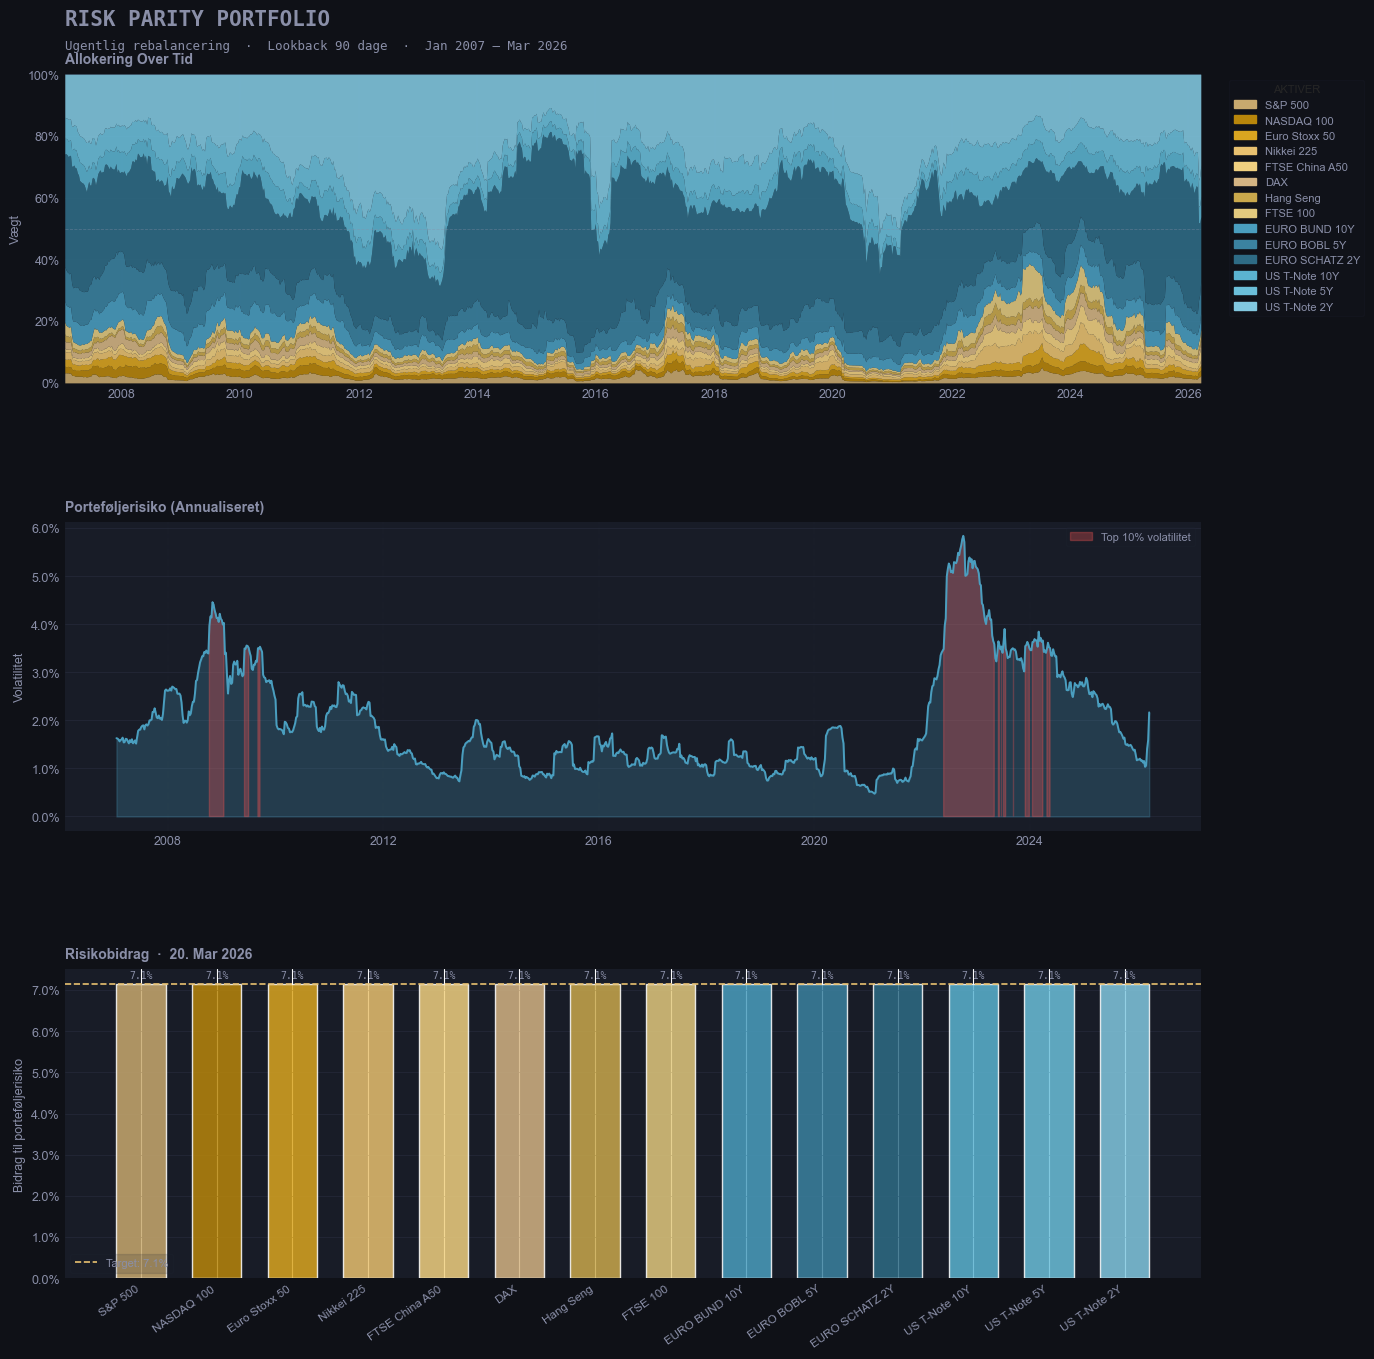

In [22]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.ticker import FuncFormatter
import matplotlib.patches as mpatches
import numpy as np

# ── Farvepalette ────────────────────────────────────────────────
EQUITY_COLORS = ['#C8A96E', '#B8860B', '#DAA520', '#E8C170', '#F0D080',
                 '#D4B483', '#C9A84C', '#E2C97E']
BOND_COLORS   = ['#4A9EBF', '#3B82A0', '#2E6B85', '#5BB3D0', '#6BBFDA', '#82C8E0']
ALL_COLORS    = EQUITY_COLORS + BOND_COLORS

BG_DARK   = '#0F1117'
BG_PANEL  = '#181C27'
#TEXT_MAIN = '#E8E8E8'
TEXT_MAIN = '#8A8FA8'
TEXT_SUB  = '#8A8FA8'
ACCENT    = '#4A9EBF'
GRID_COL  = '#252A3A'

# ── Figur-opsætning ─────────────────────────────────────────────
fig = plt.figure(figsize=(16, 14), facecolor=BG_DARK)
gs  = gridspec.GridSpec(3, 1, figure=fig, hspace=0.45,
                        top=0.93, bottom=0.07, left=0.07, right=0.78)

axes = [fig.add_subplot(gs[i]) for i in range(3)]
for ax in axes:
    ax.set_facecolor(BG_PANEL)
    ax.tick_params(colors=TEXT_SUB, labelsize=9)
    ax.xaxis.label.set_color(TEXT_SUB)
    ax.yaxis.label.set_color(TEXT_SUB)
    for spine in ax.spines.values():
        spine.set_edgecolor(GRID_COL)

# ── Supertitel ──────────────────────────────────────────────────
fig.text(0.07, 0.965, 'RISK PARITY PORTFOLIO', fontsize=15,
         fontweight='bold', color=TEXT_MAIN, fontfamily='monospace')
fig.text(0.07, 0.948, f'Ugentlig rebalancering  ·  Lookback {LOOKBACK_WINDOW} dage  ·  '
         f'{my_weights.index[0].strftime("%b %Y")} – {my_weights.index[-1].strftime("%b %Y")}',
         fontsize=9, color=TEXT_SUB, fontfamily='monospace')

# ── 1. Vægte over tid ───────────────────────────────────────────
ax0 = axes[0]
my_weights.plot(kind='area', stacked=True, ax=ax0,
                color=ALL_COLORS, alpha=0.88, linewidth=0)
ax0.set_title('Allokering Over Tid', fontsize=10, fontweight='bold',
              color=TEXT_MAIN, pad=8, loc='left')
ax0.set_ylabel('Vægt', color=TEXT_SUB, fontsize=9)
ax0.set_ylim([0, 1])
ax0.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x:.0%}'))
ax0.grid(axis='y', color=GRID_COL, linewidth=0.5)
ax0.grid(axis='x', color=GRID_COL, linewidth=0.3, linestyle=':')
ax0.set_xlabel('')

# Horisontal linje ved 50%
ax0.axhline(0.5, color=TEXT_SUB, linewidth=0.6, linestyle='--', alpha=0.4)

# Legend udenfor
handles = [mpatches.Patch(color=ALL_COLORS[i], label=col)
           for i, col in enumerate(my_weights.columns)]
ax0.legend(handles=handles, title='AKTIVER', title_fontsize=8,
           bbox_to_anchor=(1.02, 1), loc='upper left',
           fontsize=8, frameon=True, framealpha=0.15,
           facecolor=BG_PANEL, edgecolor=GRID_COL,
           labelcolor=TEXT_MAIN)

# ── 2. Porteføljerisiko ─────────────────────────────────────────
ax1 = axes[1]
vol_series = my_portfolio_vol['Portfolio Vol']

ax1.fill_between(vol_series.index, vol_series, alpha=0.25, color=ACCENT)
ax1.plot(vol_series.index, vol_series, color=ACCENT, linewidth=1.4)

# Fremhæv toppe (finanskrise + rentechok)
ax1.fill_between(vol_series.index, vol_series,
                 where=vol_series > vol_series.quantile(0.90),
                 color='#E05050', alpha=0.35, label='Top 10% volatilitet')

ax1.set_title('Porteføljerisiko (Annualiseret)', fontsize=10,
              fontweight='bold', color=TEXT_MAIN, pad=8, loc='left')
ax1.set_ylabel('Volatilitet', color=TEXT_SUB, fontsize=9)
ax1.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x:.1%}'))
ax1.grid(axis='y', color=GRID_COL, linewidth=0.5)
ax1.grid(axis='x', color=GRID_COL, linewidth=0.3, linestyle=':')
ax1.set_xlabel('')

if TARGET_VOL is not None:
    ax1.axhline(TARGET_VOL, color='#E8C170', linewidth=1.2, linestyle='--',
                label=f'Target: {TARGET_VOL:.0%}')

ax1.legend(fontsize=8, frameon=True, framealpha=0.15,
           facecolor=BG_PANEL, edgecolor=GRID_COL, labelcolor=TEXT_MAIN)

# ── 3. Risikobidrag ─────────────────────────────────────────────
ax2 = axes[2]
latest_contrib = my_risk_contrib.iloc[-1]
latest_date    = my_risk_contrib.index[-1]
n_assets       = len(latest_contrib)
x              = np.arange(n_assets)
target_rc      = 1 / n_assets

bars = ax2.bar(x, latest_contrib.values, color=ALL_COLORS[:n_assets],
               alpha=0.85, width=0.65, zorder=3)

# Afvigelse fra target som annotation
for i, (bar, val) in enumerate(zip(bars, latest_contrib.values)):
    dev = val - target_rc
    col = '#E05050' if abs(dev) > 0.005 else TEXT_SUB
    ax2.text(bar.get_x() + bar.get_width() / 2, val + 0.001,
             f'{val:.1%}', ha='center', va='bottom',
             fontsize=7, color=col, fontfamily='monospace')

ax2.axhline(target_rc, color='#E8C170', linewidth=1.2, linestyle='--',
            label=f'Target: {target_rc:.1%}', zorder=4)

ax2.set_title(f'Risikobidrag  ·  {latest_date.strftime("%d. %b %Y")}',
              fontsize=10, fontweight='bold', color=TEXT_MAIN, pad=8, loc='left')
ax2.set_ylabel('Bidrag til porteføljerisiko', color=TEXT_SUB, fontsize=9)
ax2.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x:.1%}'))
ax2.set_xticks(x)
ax2.set_xticklabels(latest_contrib.index, rotation=35, ha='right',
                    fontsize=8.5, color=TEXT_MAIN)
ax2.grid(axis='y', color=GRID_COL, linewidth=0.5, zorder=0)
ax2.set_xlabel('')
ax2.legend(fontsize=8, frameon=True, framealpha=0.15,
           facecolor=BG_PANEL, edgecolor=GRID_COL, labelcolor=TEXT_MAIN)

plt.savefig("plots/RiskParity_Alltime.png", dpi=300, transparent=False)
plt.savefig("plots/RiskParity_Alltime_Transparent.png", dpi=300, transparent=True)
plt.show()

# Plot af de seneste 6 måneder

In [7]:
# Filtrer til seneste 6 måneder
cutoff = my_weights.index[-1] - pd.DateOffset(months=6)

weights_6m      = my_weights[my_weights.index >= cutoff]
vol_6m          = my_portfolio_vol[my_portfolio_vol.index >= cutoff]
risk_contrib_6m = my_risk_contrib[my_risk_contrib.index >= cutoff]

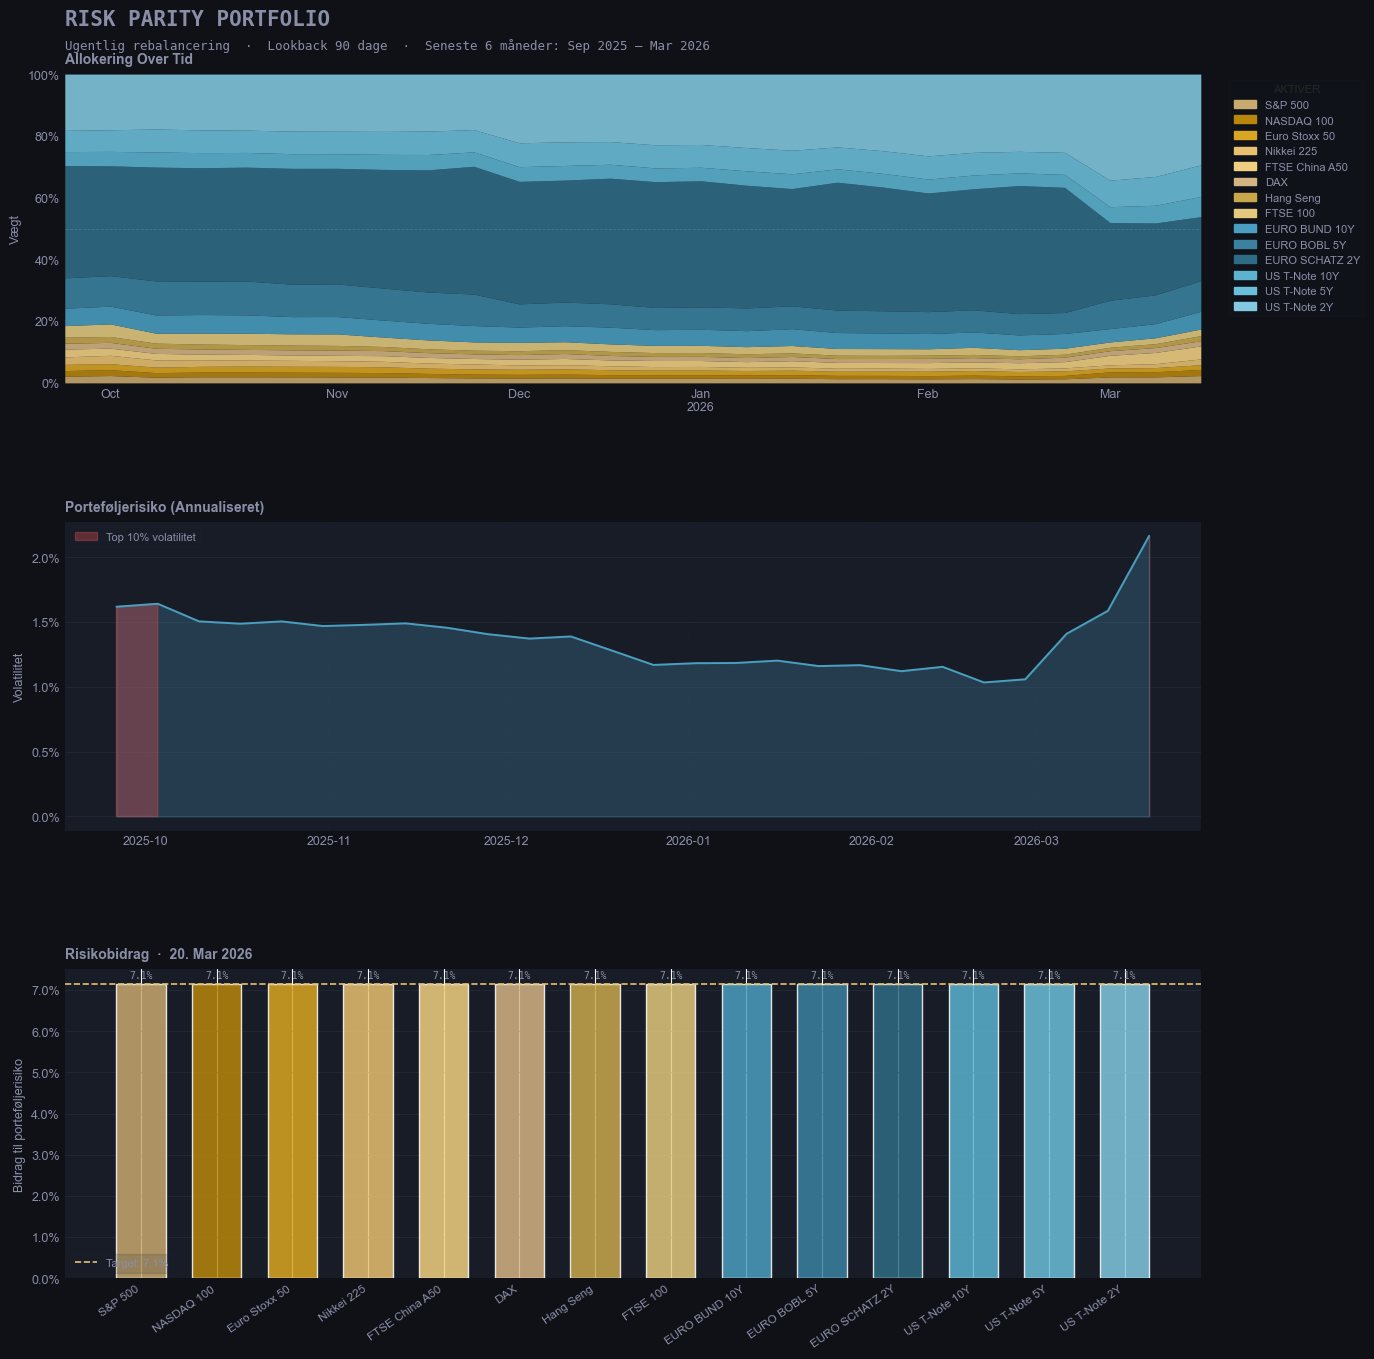

In [20]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.ticker import FuncFormatter
import matplotlib.patches as mpatches
import numpy as np

# ── Farvepalette ────────────────────────────────────────────────
EQUITY_COLORS = ['#C8A96E', '#B8860B', '#DAA520', '#E8C170', '#F0D080',
                 '#D4B483', '#C9A84C', '#E2C97E']
BOND_COLORS   = ['#4A9EBF', '#3B82A0', '#2E6B85', '#5BB3D0', '#6BBFDA', '#82C8E0']
ALL_COLORS    = EQUITY_COLORS + BOND_COLORS

BG_DARK   = '#0F1117'
BG_PANEL  = '#181C27'
#TEXT_MAIN = '#E8E8E8'
TEXT_MAIN = '#8A8FA8'
TEXT_SUB  = '#8A8FA8'
ACCENT    = '#4A9EBF'
GRID_COL  = '#252A3A'

# ── Figur-opsætning ─────────────────────────────────────────────
fig = plt.figure(figsize=(16, 14), facecolor=BG_DARK)
gs  = gridspec.GridSpec(3, 1, figure=fig, hspace=0.45,
                        top=0.93, bottom=0.07, left=0.07, right=0.78)

axes = [fig.add_subplot(gs[i]) for i in range(3)]
for ax in axes:
    ax.set_facecolor(BG_PANEL)
    ax.tick_params(colors=TEXT_SUB, labelsize=9)
    ax.xaxis.label.set_color(TEXT_SUB)
    ax.yaxis.label.set_color(TEXT_SUB)
    for spine in ax.spines.values():
        spine.set_edgecolor(GRID_COL)

# ── Supertitel ──────────────────────────────────────────────────
fig.text(0.07, 0.965, 'RISK PARITY PORTFOLIO', fontsize=15,
         fontweight='bold', color=TEXT_MAIN, fontfamily='monospace')
freq_label = {'D': 'Daglig', 'W': 'Ugentlig', 'ME': 'Månedlig', 'QE': 'Kvartalsvis'}.get(REBALANCE_FREQ, REBALANCE_FREQ)
fig.text(0.07, 0.948, f'{freq_label} rebalancering  ·  Lookback {LOOKBACK_WINDOW} dage  ·  '
         f'Seneste 6 måneder: {weights_6m.index[0].strftime("%b %Y")} – {weights_6m.index[-1].strftime("%b %Y")}',
         fontsize=9, color=TEXT_SUB, fontfamily='monospace')

# ── 1. Vægte over tid ───────────────────────────────────────────
ax0 = axes[0]
weights_6m.plot(kind='area', stacked=True, ax=ax0,
                color=ALL_COLORS, alpha=0.88, linewidth=0)
ax0.set_title('Allokering Over Tid', fontsize=10, fontweight='bold',
              color=TEXT_MAIN, pad=8, loc='left')
ax0.set_ylabel('Vægt', color=TEXT_SUB, fontsize=9)
ax0.set_ylim([0, 1])
ax0.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x:.0%}'))
ax0.grid(axis='y', color=GRID_COL, linewidth=0.5)
ax0.grid(axis='x', color=GRID_COL, linewidth=0.3, linestyle=':')
ax0.set_xlabel('')

# Horisontal linje ved 50%
ax0.axhline(0.5, color=TEXT_SUB, linewidth=0.6, linestyle='--', alpha=0.4)

# Legend udenfor
handles = [mpatches.Patch(color=ALL_COLORS[i], label=col)
           for i, col in enumerate(my_weights.columns)]
ax0.legend(handles=handles, title='AKTIVER', title_fontsize=8,
           bbox_to_anchor=(1.02, 1), loc='upper left',
           fontsize=8, frameon=True, framealpha=0.15,
           facecolor=BG_PANEL, edgecolor=GRID_COL,
           labelcolor=TEXT_MAIN)

# ── 2. Porteføljerisiko ─────────────────────────────────────────
ax1 = axes[1]
vol_series = vol_6m['Portfolio Vol']

ax1.fill_between(vol_series.index, vol_series, alpha=0.25, color=ACCENT)
ax1.plot(vol_series.index, vol_series, color=ACCENT, linewidth=1.4)

# Fremhæv toppe (finanskrise + rentechok)
ax1.fill_between(vol_series.index, vol_series,
                 where=vol_series > vol_series.quantile(0.90),
                 color='#E05050', alpha=0.35, label='Top 10% volatilitet')

ax1.set_title('Porteføljerisiko (Annualiseret)', fontsize=10,
              fontweight='bold', color=TEXT_MAIN, pad=8, loc='left')
ax1.set_ylabel('Volatilitet', color=TEXT_SUB, fontsize=9)
ax1.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x:.1%}'))
ax1.grid(axis='y', color=GRID_COL, linewidth=0.5)
ax1.grid(axis='x', color=GRID_COL, linewidth=0.3, linestyle=':')
ax1.set_xlabel('')

if TARGET_VOL is not None:
    ax1.axhline(TARGET_VOL, color='#E8C170', linewidth=1.2, linestyle='--',
                label=f'Target: {TARGET_VOL:.0%}')

ax1.legend(fontsize=8, frameon=True, framealpha=0.15,
           facecolor=BG_PANEL, edgecolor=GRID_COL, labelcolor=TEXT_MAIN)

# ── 3. Risikobidrag ─────────────────────────────────────────────
ax2 = axes[2]
latest_contrib = risk_contrib_6m.iloc[-1]
latest_date    = risk_contrib_6m.index[-1]
n_assets       = len(latest_contrib)
x              = np.arange(n_assets)
target_rc      = 1 / n_assets

bars = ax2.bar(x, latest_contrib.values, color=ALL_COLORS[:n_assets],
               alpha=0.85, width=0.65, zorder=3)

# Afvigelse fra target som annotation
for i, (bar, val) in enumerate(zip(bars, latest_contrib.values)):
    dev = val - target_rc
    col = '#E05050' if abs(dev) > 0.005 else TEXT_SUB
    ax2.text(bar.get_x() + bar.get_width() / 2, val + 0.001,
             f'{val:.1%}', ha='center', va='bottom',
             fontsize=7, color=col, fontfamily='monospace')

ax2.axhline(target_rc, color='#E8C170', linewidth=1.2, linestyle='--',
            label=f'Target: {target_rc:.1%}', zorder=4)

ax2.set_title(f'Risikobidrag  ·  {latest_date.strftime("%d. %b %Y")}',
              fontsize=10, fontweight='bold', color=TEXT_MAIN, pad=8, loc='left')
ax2.set_ylabel('Bidrag til porteføljerisiko', color=TEXT_SUB, fontsize=9)
ax2.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x:.1%}'))
ax2.set_xticks(x)
ax2.set_xticklabels(latest_contrib.index, rotation=35, ha='right',
                    fontsize=8.5, color=TEXT_MAIN)
ax2.grid(axis='y', color=GRID_COL, linewidth=0.5, zorder=0)
ax2.set_xlabel('')
ax2.legend(fontsize=8, frameon=True, framealpha=0.15,
           facecolor=BG_PANEL, edgecolor=GRID_COL, labelcolor=TEXT_MAIN)

plt.savefig("plots/RiskParity_6M.png", dpi=300, transparent=False)
plt.savefig("plots/RiskParity_6M_Transparent.png", dpi=300, transparent=True)
plt.show()

In [9]:
# Sammenlign faktiske vægte historisk vs. seneste 6M
print("Gennemsnitlige vægte — hele perioden:")
print(my_weights.mean().to_string())

print("\nGennemsnitlige vægte — seneste 6 måneder:")
print(weights_6m.mean().to_string())

print("\nSeneste vægte:")
print(my_weights.iloc[-1].to_string())

Gennemsnitlige vægte — hele perioden:
S&P 500          0.0195
NASDAQ 100       0.0170
Euro Stoxx 50    0.0169
Nikkei 225       0.0190
FTSE China A50   0.0168
DAX              0.0177
Hang Seng        0.0142
FTSE 100         0.0219
EURO BUND 10Y    0.0495
EURO BOBL 5Y     0.0855
EURO SCHATZ 2Y   0.3363
US T-Note 10Y    0.0517
US T-Note 5Y     0.0774
US T-Note 2Y     0.2566

Gennemsnitlige vægte — seneste 6 måneder:
S&P 500          0.0170
NASDAQ 100       0.0136
Euro Stoxx 50    0.0162
Nikkei 225       0.0148
FTSE China A50   0.0214
DAX              0.0152
Hang Seng        0.0132
FTSE 100         0.0268
EURO BUND 10Y    0.0529
EURO BOBL 5Y     0.0874
EURO SCHATZ 2Y   0.3717
US T-Note 10Y    0.0475
US T-Note 5Y     0.0758
US T-Note 2Y     0.2267

Seneste vægte:
S&P 500          0.0237
NASDAQ 100       0.0198
Euro Stoxx 50    0.0153
Nikkei 225       0.0188
FTSE China A50   0.0422
DAX              0.0167
Hang Seng        0.0167
FTSE 100         0.0213
EURO BUND 10Y    0.0573
EURO BOBL 5Y   